# Explainable Loan Default Risk Scoring System

## Phase 1: Data Exploration

### Project Objective

The objective of this project is to build an explainable machine learning system that predicts whether a customer is likely to default on a loan.

Rather than focusing only on prediction accuracy, this project also emphasizes:

- Understanding the data
- Identifying important features
- Building interpretable models
- Generating risk scores
- Explaining predictions using Explainable AI (SHAP)

This notebook focuses on understanding the dataset before any preprocessing or model development.

## Business Problem

Banks receive thousands of loan applications every day.

Approving loans for customers who later default results in financial losses, while rejecting reliable customers reduces business opportunities.

The objective is to build a model that helps estimate the probability of loan default using applicant information.

The final system will classify applicants into different risk categories and provide explanations for its predictions.

## Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing the dataframe
pd.set_option("display.max_columns", None)

## Step 2: Load Dataset

In [4]:
df = pd.read_csv("../data/Loan_Default.csv")

## Step 3: Display First Five Rows

In [5]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Step 4: Understand Dataset Structure

In [6]:
df.shape


(255347, 18)

### Observation

In [7]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

### Observation

- The dataset contains **255,347 loan records**.
- It has **18 columns**, including customer attributes and the target variable.
- The dataset is sufficiently large for training machine learning models.

### Observation

- The dataset contains **255,347 records** and **18 columns**.
- There are **no missing values** in any column.
- The dataset contains a mix of **numerical** and **categorical** features.
- The `LoanID` column is an identifier and is not expected to contribute to prediction.
- The `Default` column is the target variable for the classification task.

In [9]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Summary statistics
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [11]:
# Target variable distribution
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [12]:
# Target variable percentage
df["Default"].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

## Step 6: Visual Exploratory Data Analysis

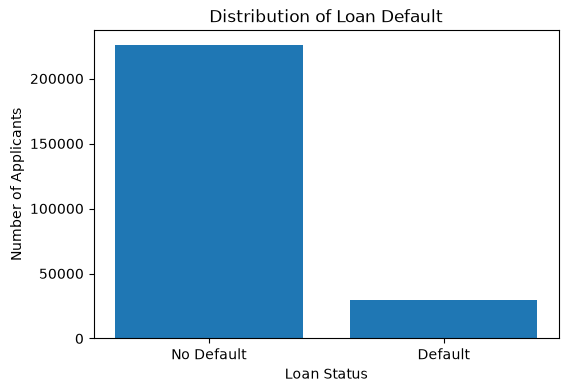

In [13]:
import matplotlib.pyplot as plt

default_counts = df["Default"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["No Default", "Default"], default_counts.values)

plt.title("Distribution of Loan Default")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

- Most applicants did not default on their loans.
- The dataset is clearly imbalanced, with approximately 88% non-default cases and 12% default cases.
- Accuracy alone may not be an appropriate evaluation metric because a model could achieve high accuracy by always predicting the majority class.

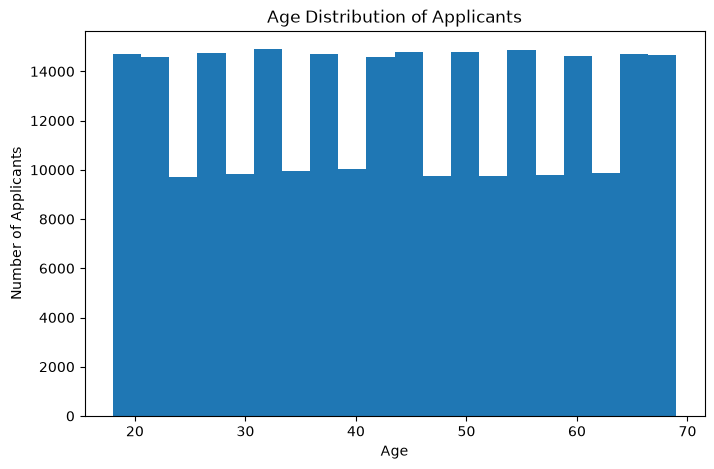

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution of Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

- Applicants are distributed across a wide age range from 18 to 69 years.
- No unrealistic age values are present.
- The dataset represents both younger and older borrowers.

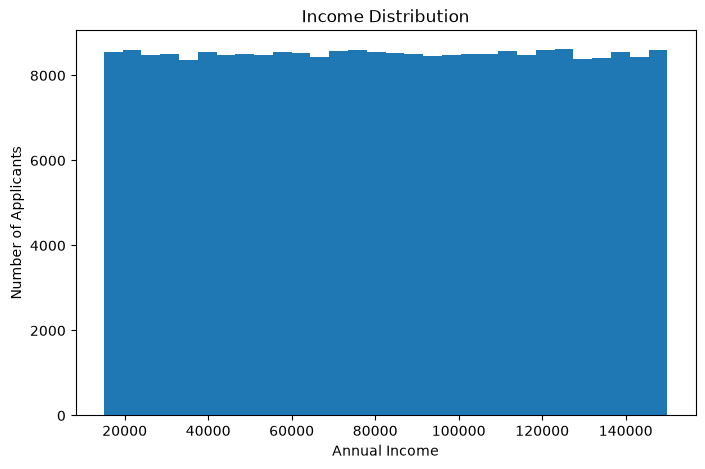

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["Income"], bins=30)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

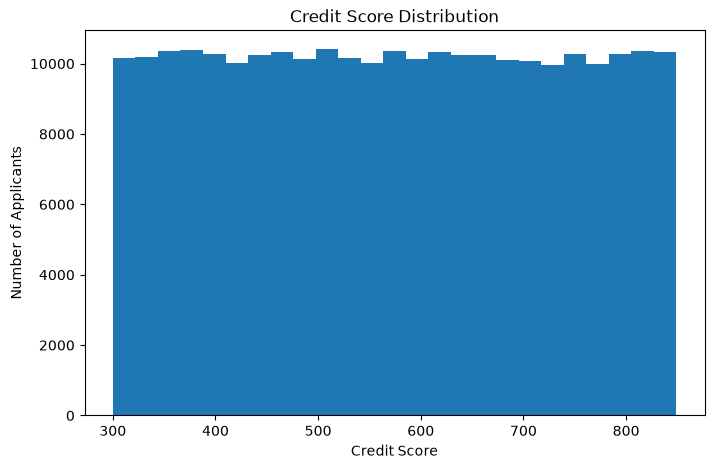

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["CreditScore"], bins=25)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.show()

## Step 7: Outlier Analysis

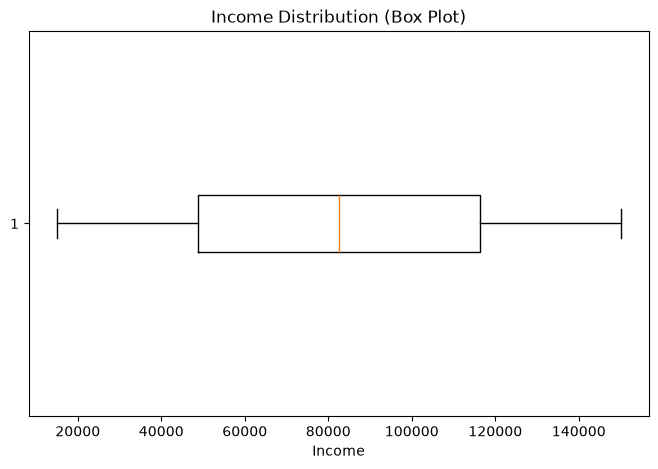

In [17]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Income"], orientation="horizontal")

plt.title("Income Distribution (Box Plot)")
plt.xlabel("Income")

plt.show()

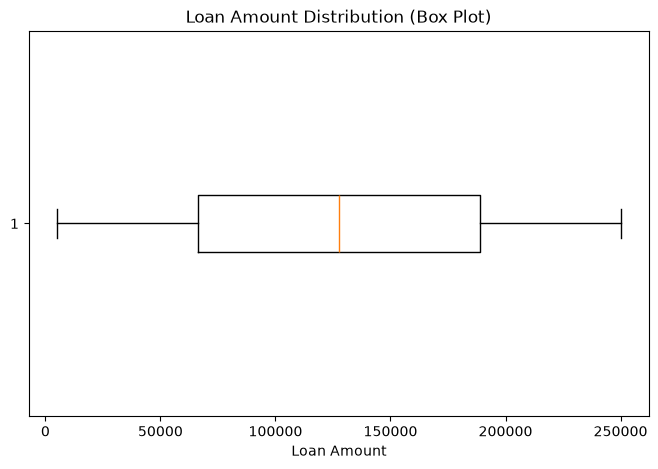

In [18]:
plt.figure(figsize=(8,5))

plt.boxplot(df["LoanAmount"], orientation="horizontal")

plt.title("Loan Amount Distribution (Box Plot)")
plt.xlabel("Loan Amount")

plt.show()

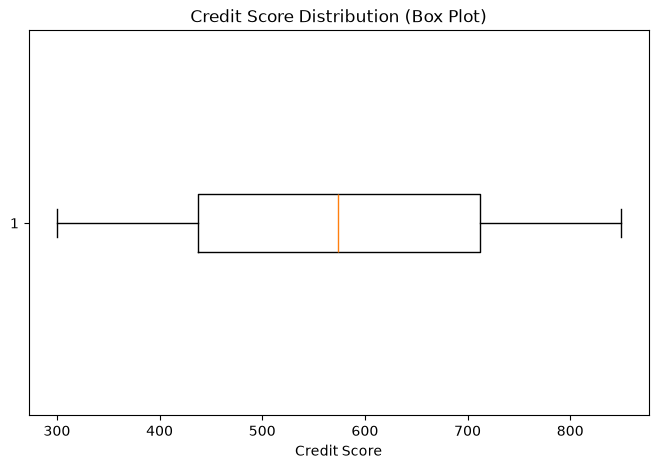

In [19]:
plt.figure(figsize=(8,5))

plt.boxplot(df["CreditScore"], orientation="horizontal")

plt.title("Credit Score Distribution (Box Plot)")
plt.xlabel("Credit Score")

plt.show()

## Step 8: Feature vs Target Analysis

In [20]:
df.groupby("Default")["CreditScore"].mean()

Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64

In [21]:
df.groupby("Default")["Income"].mean()

Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64

In [22]:
df.groupby("Default")["LoanAmount"].mean()

Default
0    125353.656017
1    144515.311469
Name: LoanAmount, dtype: float64

In [23]:
df.groupby("Default")["DTIRatio"].mean()

Default
0    0.498602
1    0.512467
Name: DTIRatio, dtype: float64

## Step 9: Correlation Analysis

In [24]:
corr = df.corr(numeric_only=True)

corr

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


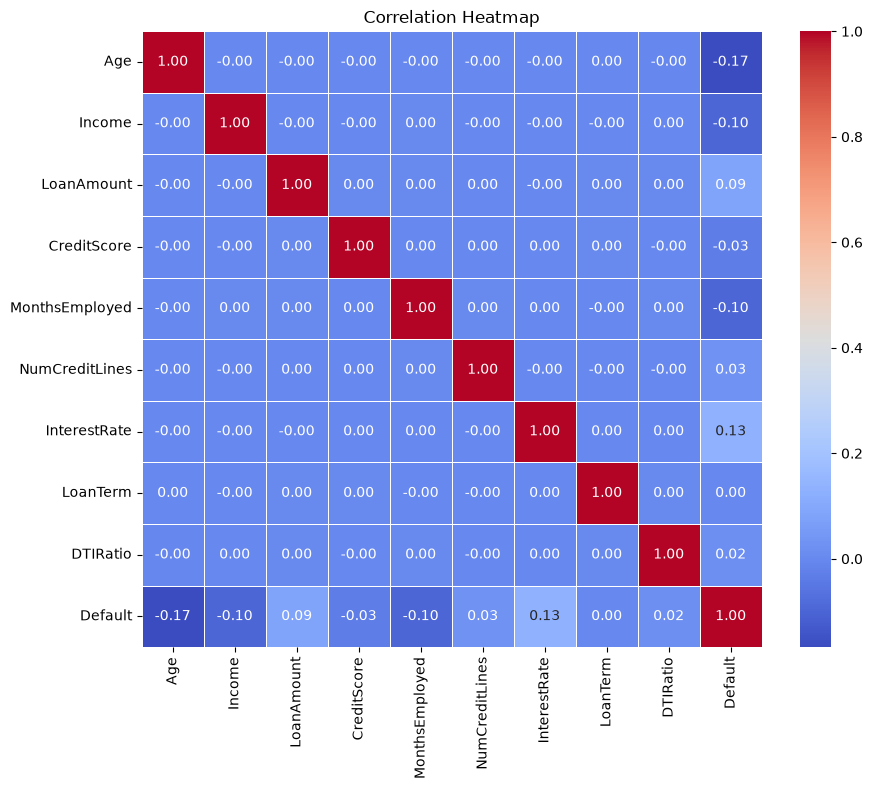

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The correlation heatmap shows the relationship among numerical features.
- Most variables have weak to moderate correlations.
- No pair of numerical variables appears to have extremely high correlation, indicating a low risk of multicollinearity.

## Step 10: Categorical Feature Analysis

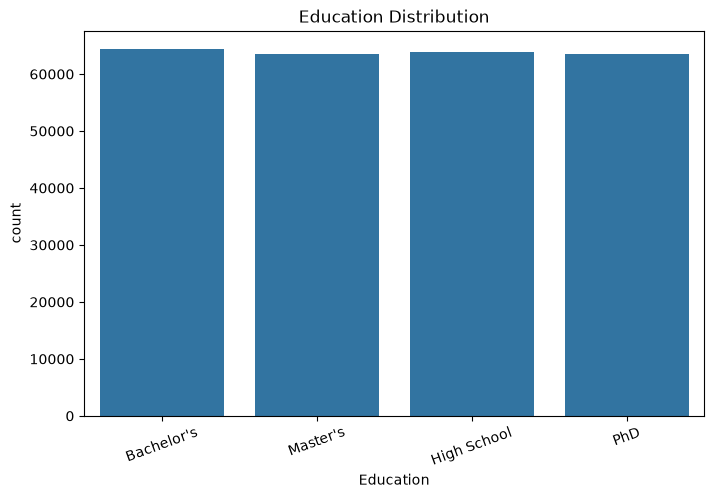

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Education")

plt.title("Education Distribution")
plt.xticks(rotation=20)

plt.show()

### Observation

- The dataset contains applicants from different educational backgrounds.
- Education may influence income level and repayment capability.

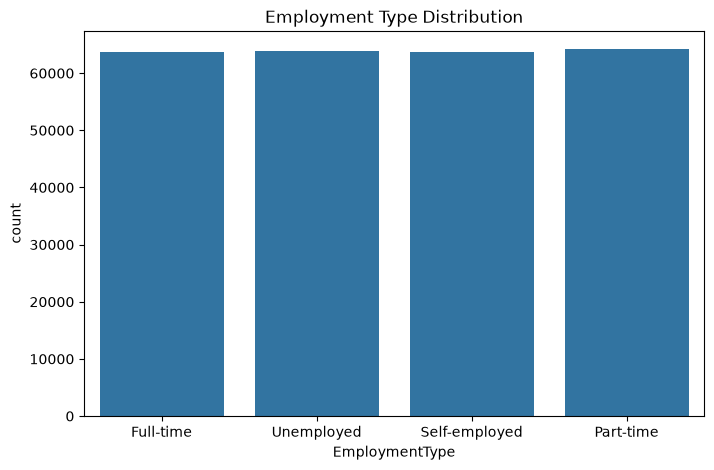

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="EmploymentType")

plt.title("Employment Type Distribution")

plt.show()

### Observation

- Applicants belong to different employment categories.
- Employment stability can affect loan repayment behavior.

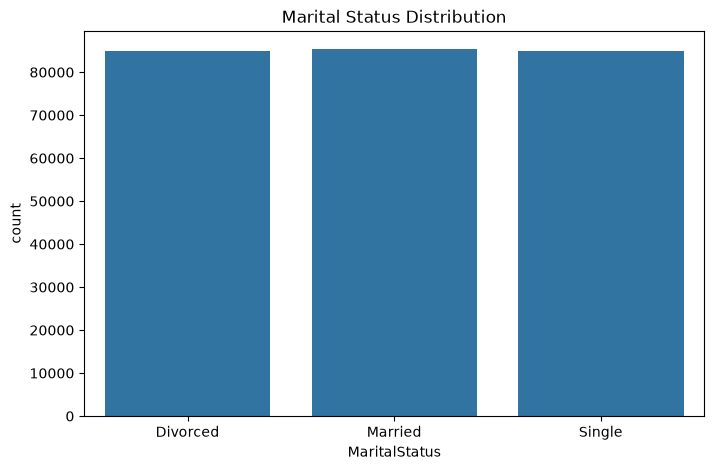

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="MaritalStatus")

plt.title("Marital Status Distribution")

plt.show()

### Observation

- Applicants have different marital statuses.
- Family responsibilities may indirectly influence financial commitments.

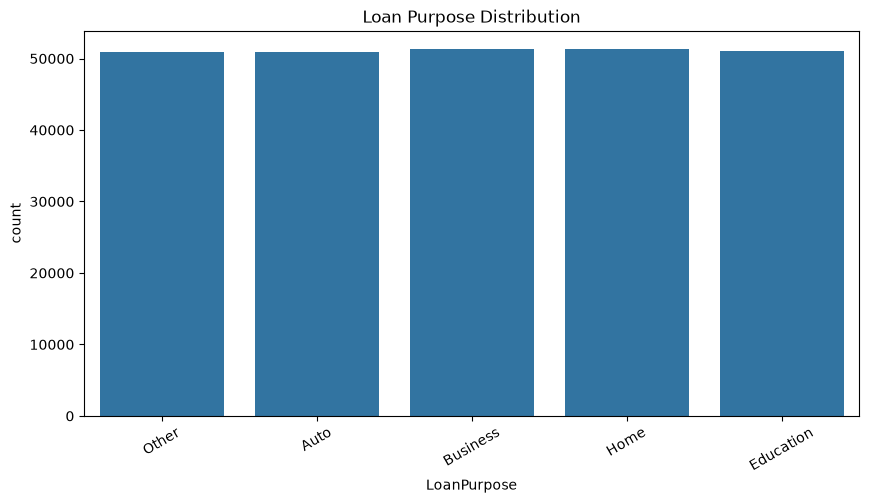

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="LoanPurpose")

plt.title("Loan Purpose Distribution")

plt.xticks(rotation=30)

plt.show()

### Observation

- Loans are requested for multiple purposes.
- Loan purpose could influence the probability of default.

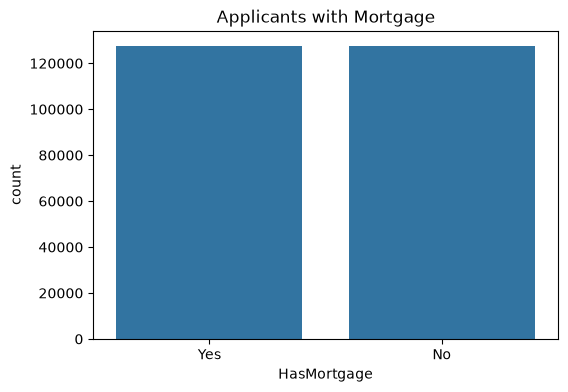

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="HasMortgage")

plt.title("Applicants with Mortgage")

plt.show()

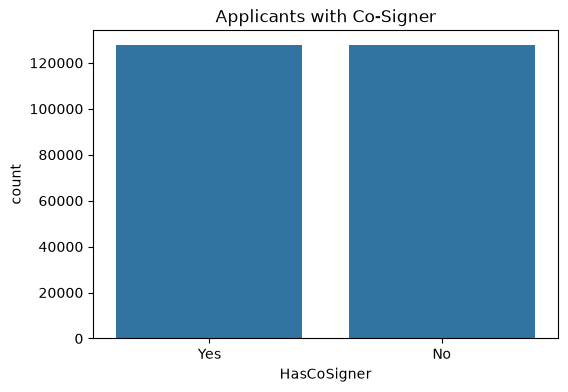

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="HasCoSigner")

plt.title("Applicants with Co-Signer")

plt.show()

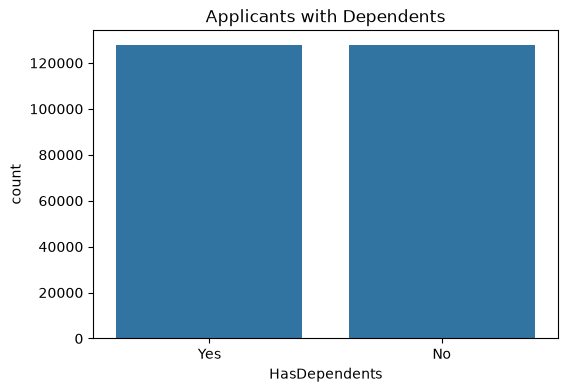

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="HasDependents")

plt.title("Applicants with Dependents")

plt.show()

## Step 11: Business Analysis - Default Rate by Category

In [33]:
education_default = (
    df.groupby("Education")["Default"]
    .mean()
    .sort_values(ascending=False)
)

education_default

Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64

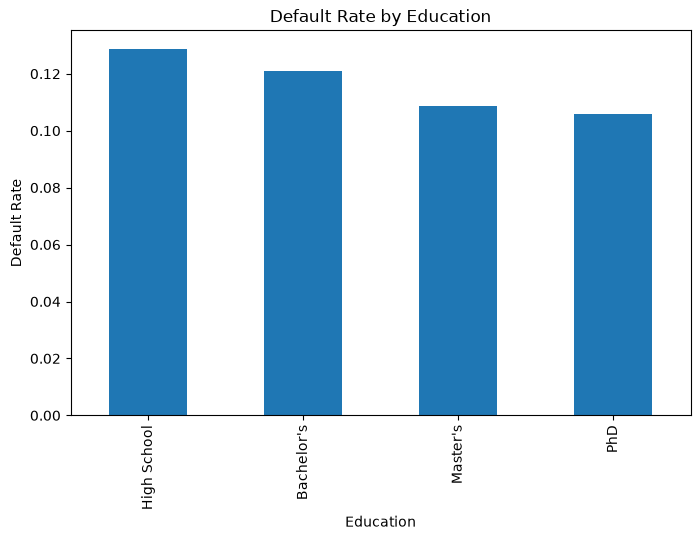

In [34]:
plt.figure(figsize=(8,5))

education_default.plot(kind="bar")

plt.title("Default Rate by Education")
plt.ylabel("Default Rate")

plt.show()

In [35]:
employment_default = (
    df.groupby("EmploymentType")["Default"]
    .mean()
    .sort_values(ascending=False)
)

employment_default

EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64

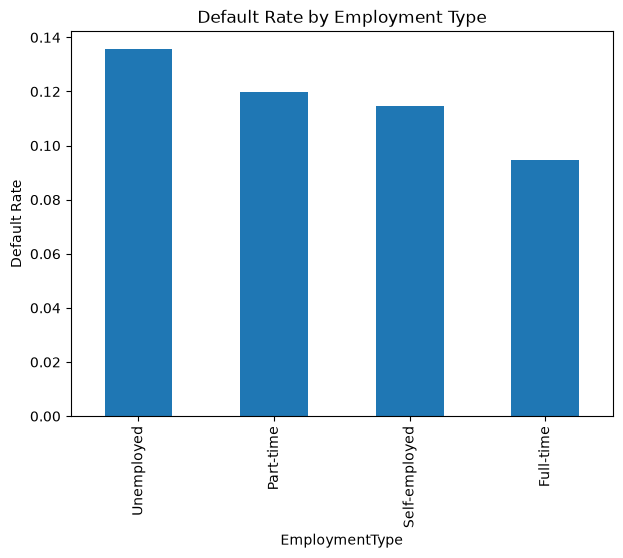

In [36]:
plt.figure(figsize=(7,5))

employment_default.plot(kind="bar")

plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")

plt.show()

In [37]:
marital_default = (
    df.groupby("MaritalStatus")["Default"]
    .mean()
    .sort_values(ascending=False)
)

marital_default

MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64

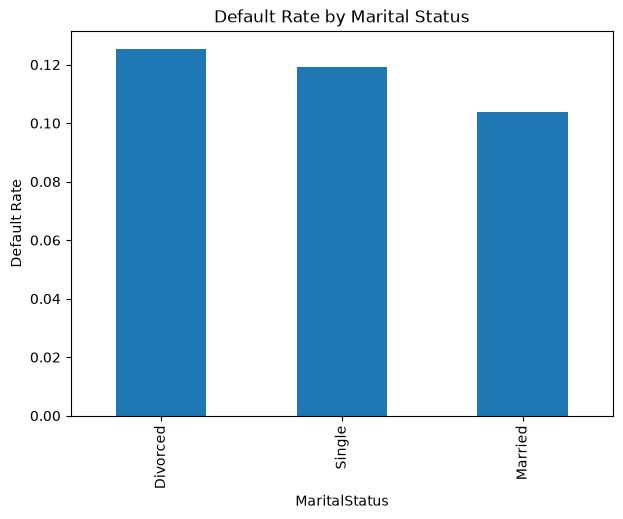

In [38]:
plt.figure(figsize=(7,5))

marital_default.plot(kind="bar")

plt.title("Default Rate by Marital Status")
plt.ylabel("Default Rate")

plt.show()

In [39]:
loanpurpose_default = (
    df.groupby("LoanPurpose")["Default"]
    .mean()
    .sort_values(ascending=False)
)

loanpurpose_default

LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64

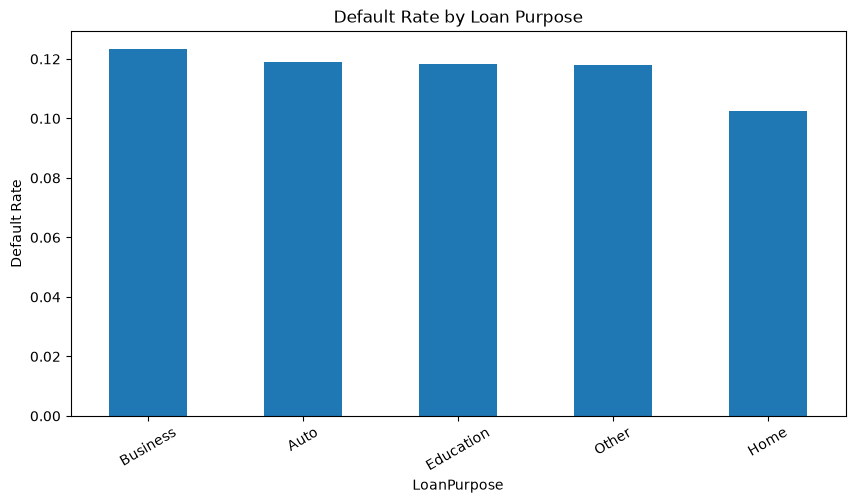

In [40]:
plt.figure(figsize=(10,5))

loanpurpose_default.plot(kind="bar")

plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")

plt.xticks(rotation=30)

plt.show()

# Step 12: Exploratory Data Analysis Summary

## Dataset Overview
- Total Records: 255,347
- Total Features: 18
- Target Variable: Default

## Data Quality
- No missing values were found.
- No duplicate records were found.
- Data types are appropriate for analysis.

## Target Variable
- Approximately 88% of applicants did not default.
- Approximately 12% of applicants defaulted.
- The dataset is imbalanced, which should be considered during model training.

## Numerical Features
- Credit Score, Income, Loan Amount, and DTI Ratio are important financial indicators.
- Numerical features contain outliers, but they appear realistic for financial data.

## Categorical Features
- The dataset contains multiple categorical variables including Education, Employment Type, Marital Status, Loan Purpose, Mortgage Status, Dependents, and Co-signer information.
- Most categorical features are fairly balanced because the dataset is synthetically generated.

## Business Insights
- Customer financial characteristics are expected to play a significant role in predicting loan default.
- Credit-related features and debt burden are likely to be among the most influential predictors.
- Further preprocessing, feature engineering, and explainable machine learning techniques will be applied in the next stages.

## Conclusion
The dataset is clean, complete, and suitable for building an explainable loan default prediction system.